# V-Beam Thermal Sensor - MLP Forward Model: Grid Search + Training

**What this notebook does:**
1. Grid-searches MLP hyperparameters (60 combinations)
2. Re-trains the best configuration at full budget
3. Evaluates on the held-out test set (parity plots + MAPE/RMSE/MAE)
4. Saves the model weights + scalers to `../Models/`

> Run `gradient-descent.ipynb` to load the saved model and perform inverse design.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import itertools
import time
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
np.random.seed(42)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU not found. Install CUDA-enabled PyTorch: "
        "https://pytorch.org/get-started/locally/"
    )
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB


## 2. Load Data

In [3]:
EXCEL_PATH = "../Data/Datasets/Dataset_complet_5.11.2025.xlsx"

df = pd.read_excel(EXCEL_PATH)
print(f"Dataset shape: {df.shape}")

INPUT_COLS  = ["Beta Angle", "Beam Length", "Beam Width",
               "Delta Temp", "Young's Modulus - E", "CTE - alpha"]
OUTPUT_COLS = ["Sensor Displacement", "Max Mechanical Stress", "Vol"]

df_clean = df[INPUT_COLS + OUTPUT_COLS].dropna()
print(f"Clean rows: {len(df_clean)}")
print()
print(df_clean.describe())

Dataset shape: (3000, 30)
Clean rows: 3000

        Beta Angle  Beam Length   Beam Width   Delta Temp  \
count  3000.000000  3000.000000  3000.000000  3000.000000   
mean     24.993200    27.510467     1.499800    45.292500   
std       8.670222     4.281793     0.295583    14.446169   
min      10.000000    20.000000     1.000000    20.000000   
25%      17.600000    23.800000     1.200000    32.800000   
50%      24.850000    27.600000     1.500000    45.100000   
75%      32.500000    31.200000     1.800000    57.900000   
max      40.000000    35.000000     2.000000    70.000000   

       Young's Modulus - E   CTE - alpha  Sensor Displacement  \
count               3000.0  3.000000e+03          3000.000000   
mean               71000.0  2.300000e-05             0.090790   
std                    0.0  3.388697e-21             0.042193   
min                71000.0  2.300000e-05             0.024984   
25%                71000.0  2.300000e-05             0.059721   
50%             

## 2.1. Filtering samples (optional)

Filter samples based on the value of sensor displacement.


In [6]:
mask = ~df_clean["Sensor Displacement"].between(0.15, 0.3)
df_clean = df_clean[mask]
print(f"Clean rows after filtering: {len(df_clean)}")

Clean rows after filtering: 2726


## 3. Preprocessing

Convert the data into numpy arrays.

In [7]:
X_raw = df_clean[INPUT_COLS].values.astype(np.float32)
Y_raw = df_clean[OUTPUT_COLS].values.astype(np.float32)

print("X shape:", X_raw.shape, "  Y shape:", Y_raw.shape)
print("Input columns :", INPUT_COLS)
print("Output columns:", OUTPUT_COLS)

X shape: (2726, 6)   Y shape: (2726, 3)
Input columns : ['Beta Angle', 'Beam Length', 'Beam Width', 'Delta Temp', "Young's Modulus - E", 'CTE - alpha']
Output columns: ['Sensor Displacement', 'Max Mechanical Stress', 'Vol']


## 4. Train / Validation / Test Split

Random 70 / 15 / 15 split (seed = 42).

Use Standard Scaler to normalize the data.

In [8]:
rng = np.random.default_rng(42)
all_indices = np.arange(len(X_raw))
shuffled    = rng.permutation(all_indices)

n       = len(shuffled)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_indices = shuffled[:n_train]
val_indices   = shuffled[n_train:n_train + n_val]
test_indices  = shuffled[n_train + n_val:]

scaler_x = StandardScaler()
scaler_y = StandardScaler()

scaler_x.fit(X_raw[train_indices])
scaler_y.fit(Y_raw[train_indices])

X_scaled = scaler_x.transform(X_raw).astype(np.float32)
Y_scaled = scaler_y.transform(Y_raw).astype(np.float32)

X_tensor = torch.from_numpy(X_scaled)
Y_tensor = torch.from_numpy(Y_scaled)

full_dataset = TensorDataset(X_tensor, Y_tensor)
train_set    = Subset(full_dataset, train_indices.tolist())
val_set      = Subset(full_dataset, val_indices.tolist())
test_set     = Subset(full_dataset, test_indices.tolist())

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")

Train: 1908  |  Val: 408  |  Test: 410


## 5. MLP Architecture

Fully-connected network with BatchNorm and Dropout.

In [9]:
class MLPForwardNet(nn.Module):
    def __init__(self, in_dim=6, out_dim=3, hidden_sizes=(128, 128), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

demo = MLPForwardNet().to(device)
print(f"Demo MLP parameters (128,128, drop=0.1): {sum(p.numel() for p in demo.parameters()):,}")
del demo

Demo MLP parameters (128,128, drop=0.1): 18,307


## 6. Training Utility

Adam + ReduceLROnPlateau + gradient clipping + early stopping.

In [10]:
def make_loaders(batch_size):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              pin_memory=(device.type == "cuda"))
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type == "cuda"))
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type == "cuda"))
    return train_loader, val_loader, test_loader


def train_model(model, train_loader, val_loader,
                epochs=500, patience=30, lr=1e-3, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=15, verbose=False)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += criterion(model(xb), yb).item() * len(xb)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"  Epoch {epoch:4d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} "
                  f"| LR: {optimizer.param_groups[0]['lr']:.2e}")

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_val_loss

## 7. Grid Search

60 combinations × 200 epochs each.

In [11]:
PARAM_GRID = {
    "hidden_sizes" : [(64, 64), (128, 128), (256, 128), (256, 256), (512, 256, 128)],
    "dropout"      : [0.0, 0.1, 0.2],
    "lr"           : [1e-3, 5e-4],
    "batch_size"   : [64, 128],
}
GS_EPOCHS   = 200
GS_PATIENCE = 20

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*PARAM_GRID.values()))
print(f"Total combinations: {len(combos)}")

Total combinations: 60


In [12]:
gs_results     = []
best_gs_val    = float("inf")
best_gs_params = None

start = time.time()

for i, combo in enumerate(combos, 1):
    params = dict(zip(keys, combo))
    hs, dr, lr, bs = params["hidden_sizes"], params["dropout"], params["lr"], params["batch_size"]
    print(f"[{i:2d}/{len(combos)}] hidden={hs}  dropout={dr}  lr={lr}  batch={bs}")

    train_loader, val_loader, _ = make_loaders(bs)
    m = MLPForwardNet(in_dim=len(INPUT_COLS), out_dim=len(OUTPUT_COLS),
                      hidden_sizes=hs, dropout=dr).to(device)
    _, _, best_val = train_model(m, train_loader, val_loader,
                                  epochs=GS_EPOCHS, patience=GS_PATIENCE, lr=lr, verbose=False)
    print(f"         -> best val MSE: {best_val:.6f}")
    gs_results.append({**params, "best_val_mse": best_val})

    if best_val < best_gs_val:
        best_gs_val    = best_val
        best_gs_params = params.copy()

elapsed = time.time() - start
print(f"\nGrid search completed in {elapsed/60:.1f} min")
print(f"Best val MSE : {best_gs_val:.6f}")
print(f"Best params  : {best_gs_params}")

[ 1/60] hidden=(64, 64)  dropout=0.0  lr=0.001  batch=64


C:\Users\tudor\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


         -> best val MSE: 0.056170
[ 2/60] hidden=(64, 64)  dropout=0.0  lr=0.001  batch=128
         -> best val MSE: 0.055365
[ 3/60] hidden=(64, 64)  dropout=0.0  lr=0.0005  batch=64
         -> best val MSE: 0.056361
[ 4/60] hidden=(64, 64)  dropout=0.0  lr=0.0005  batch=128
         -> best val MSE: 0.055289
[ 5/60] hidden=(64, 64)  dropout=0.1  lr=0.001  batch=64
         -> best val MSE: 0.056908
[ 6/60] hidden=(64, 64)  dropout=0.1  lr=0.001  batch=128
         -> best val MSE: 0.056954
[ 7/60] hidden=(64, 64)  dropout=0.1  lr=0.0005  batch=64
         -> best val MSE: 0.058439
[ 8/60] hidden=(64, 64)  dropout=0.1  lr=0.0005  batch=128
         -> best val MSE: 0.057150
[ 9/60] hidden=(64, 64)  dropout=0.2  lr=0.001  batch=64
         -> best val MSE: 0.058171
[10/60] hidden=(64, 64)  dropout=0.2  lr=0.001  batch=128
         -> best val MSE: 0.058502
[11/60] hidden=(64, 64)  dropout=0.2  lr=0.0005  batch=64
         -> best val MSE: 0.060865
[12/60] hidden=(64, 64)  dropout=0.

Top 10 configurations:
   hidden_sizes  dropout     lr  batch_size  best_val_mse
(512, 256, 128)      0.1 0.0010         128      0.054172
(512, 256, 128)      0.0 0.0005          64      0.054185
(512, 256, 128)      0.0 0.0010          64      0.054226
(512, 256, 128)      0.1 0.0005         128      0.054250
(512, 256, 128)      0.0 0.0010         128      0.054727
     (128, 128)      0.0 0.0005         128      0.054728
(512, 256, 128)      0.1 0.0010          64      0.054888
     (256, 256)      0.0 0.0005          64      0.055014
     (256, 128)      0.0 0.0005          64      0.055091
(512, 256, 128)      0.2 0.0010         128      0.055105


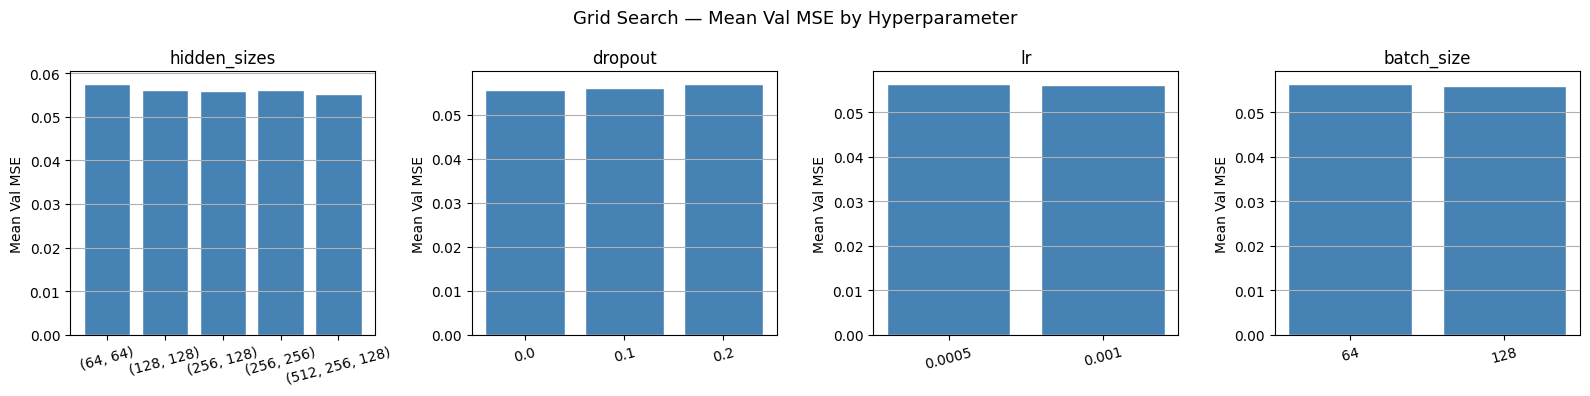

In [13]:
gs_df = pd.DataFrame(gs_results).sort_values("best_val_mse").reset_index(drop=True)
print("Top 10 configurations:")
print(gs_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key in zip(axes, ["hidden_sizes", "dropout", "lr", "batch_size"]):
    group  = gs_df.groupby(key)["best_val_mse"].mean().reset_index()
    labels = [str(v) for v in group[key]]
    ax.bar(labels, group["best_val_mse"], color="steelblue", edgecolor="white")
    ax.set_title(key); ax.set_ylabel("Mean Val MSE")
    ax.tick_params(axis="x", rotation=15); ax.grid(axis="y")
plt.suptitle("Grid Search — Mean Val MSE by Hyperparameter", fontsize=13)
plt.tight_layout(); plt.show()

## 8. Full Training of Best Configuration

500 epochs, patience = 30.

In [14]:
print(f"Re-training best config: {best_gs_params}\n")

train_loader, val_loader, test_loader = make_loaders(best_gs_params["batch_size"])

model = MLPForwardNet(
    in_dim=len(INPUT_COLS), out_dim=len(OUTPUT_COLS),
    hidden_sizes=best_gs_params["hidden_sizes"],
    dropout=best_gs_params["dropout"]
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

train_losses, val_losses, best_val_loss = train_model(
    model, train_loader, val_loader,
    epochs=500, patience=30, lr=best_gs_params["lr"], verbose=True
)
print(f"\nFinal best validation loss: {best_val_loss:.5f}")

Re-training best config: {'hidden_sizes': (512, 256, 128), 'dropout': 0.1, 'lr': 0.001, 'batch_size': 128}

Model parameters: 169,987
MLPForwardNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=3, bias=True)
  )
)
  Epoch    1 | Train: 0.22309 | Val: 0.22656 | LR: 1.00e-03


C:\Users\tudor\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch   20 | Train: 0.08119 | Val: 0.05977 | LR: 1.00e-03
  Epoch   40 | Train: 0.06955 | Val: 0.05837 | LR: 1.00e-03
  Epoch   60 | Train: 0.07497 | Val: 0.05806 | LR: 1.00e-03
  Epoch   80 | Train: 0.06282 | Val: 0.05501 | LR: 5.00e-04
  Early stopping at epoch 87

Final best validation loss: 0.05469


## 9. Evaluate on Test Set

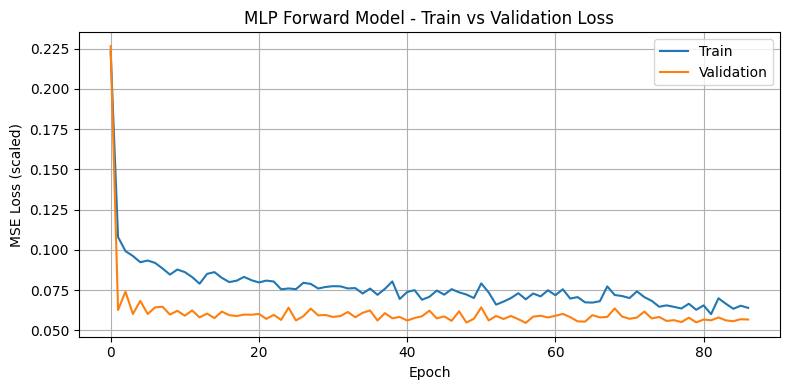

MLP Forward Model - Test Set Performance (physical units)
-----------------------------------------------------------------
  Sensor Displacement             MAE=0.0070   RMSE=0.0121   MAPE=9.15%
  Max Mechanical Stress           MAE=1.6341   RMSE=2.4936   MAPE=2.68%
  Vol                             MAE=2.6826   RMSE=3.4854   MAPE=0.43%


In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train"); plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss (scaled)")
plt.title("MLP Forward Model - Train vs Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

model.eval()
preds_scaled, trues_scaled = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_scaled.append(model(xb.to(device)).cpu())
        trues_scaled.append(yb)

preds_scaled = torch.cat(preds_scaled).numpy()
trues_scaled = torch.cat(trues_scaled).numpy()

preds_phys = scaler_y.inverse_transform(preds_scaled)
trues_phys = scaler_y.inverse_transform(trues_scaled)

mae  = np.mean(np.abs(preds_phys - trues_phys), axis=0)
rmse = np.sqrt(np.mean((preds_phys - trues_phys) ** 2, axis=0))
mape = np.mean(np.abs((preds_phys - trues_phys) / trues_phys) * 100, axis=0)

print("MLP Forward Model - Test Set Performance (physical units)")
print("-" * 65)
for i, col in enumerate(OUTPUT_COLS):
    print(f"  {col:<30s}  MAE={mae[i]:.4f}   RMSE={rmse[i]:.4f}   MAPE={mape[i]:.2f}%")

## 10. Parity Plots

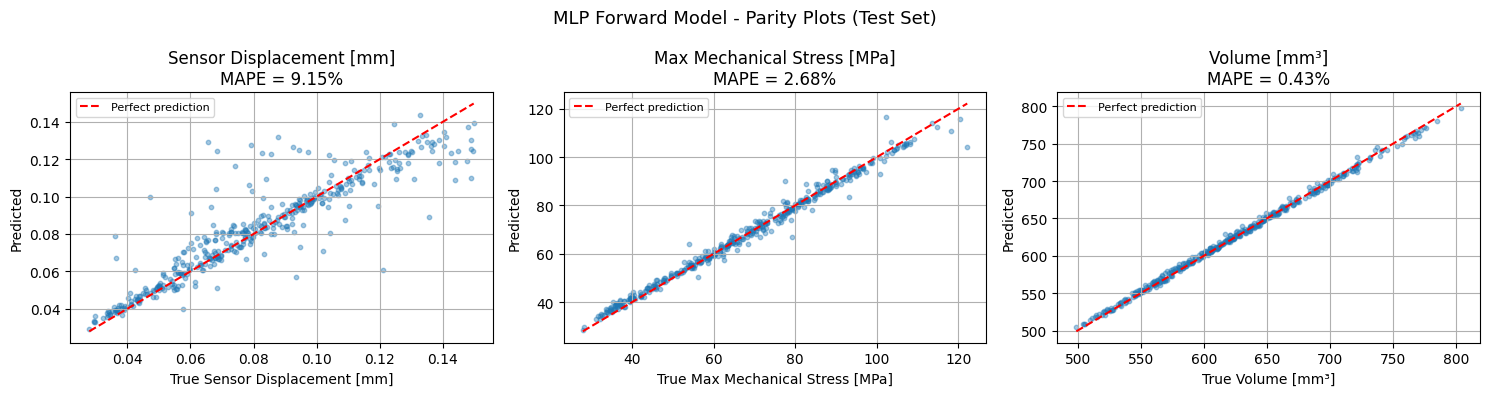

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["Sensor Displacement [mm]", "Max Mechanical Stress [MPa]", "Volume [mm³]"]

for i, ax in enumerate(axes):
    ax.scatter(trues_phys[:, i], preds_phys[:, i], alpha=0.4, s=10)
    lims = [min(trues_phys[:, i].min(), preds_phys[:, i].min()),
            max(trues_phys[:, i].max(), preds_phys[:, i].max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel(f"True {labels[i]}"); ax.set_ylabel("Predicted")
    ax.set_title(f"{labels[i]}\nMAPE = {mape[i]:.2f}%")
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("MLP Forward Model - Parity Plots (Test Set)", fontsize=13)
plt.tight_layout(); plt.show()

## 11. Save Model

Saves `mlp_forward_model.pt` (state dict + config) and `mlp_scalers.pkl` to `../Models/`.

In [17]:
import joblib

MODEL_DIR = "../Models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path  = os.path.join(MODEL_DIR, "mlp_filtered_forward_model.pt")
scaler_path = os.path.join(MODEL_DIR, "mlp_filtered_scalers.pkl")

torch.save({
    "model_state_dict": model.state_dict(),
    "best_params"     : best_gs_params,
    "input_cols"      : INPUT_COLS,
    "output_cols"     : OUTPUT_COLS,
    "test_indices"    : test_indices.tolist(),
}, model_path)

joblib.dump({"scaler_x": scaler_x, "scaler_y": scaler_y}, scaler_path)

print(f"Model saved to  : {model_path}")
print(f"Scalers saved to: {scaler_path}")

Model saved to  : ../Models\mlp_filtered_forward_model.pt
Scalers saved to: ../Models\mlp_filtered_scalers.pkl
